In [1]:
import numpy as np
import xarray as xr
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform
import pickle
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

In [2]:
with open('aus_region_mask.pkl','rb') as f:
    lsmdf = pickle.load(f)
with open('aus_region_mask_lsmc.pkl','rb') as f:
    lsmc = pickle.load(f)
with open('wind_correlation_matrix.pkl','rb') as f:
    rlsmcs5Wmnavg = pickle.load(f)

In [3]:
pdist = pairwise_distances(rlsmcs5Wmnavg)
linkage = sch.linkage(squareform(pdist.astype('float32')), method='complete')
ninds0 = 15 #hard code
idx = sch.fcluster(linkage, ninds0, 'maxclust')
idxmap = np.empty((np.shape(lsmc)[0]*np.shape(lsmc)[1]))*np.nan
inds = np.ndarray.flatten(np.argwhere(np.ndarray.flatten(lsmc)==1))
idxmap[inds] = idx
idxmap = idxmap.reshape(np.shape(lsmc)[0],np.shape(lsmc)[1])

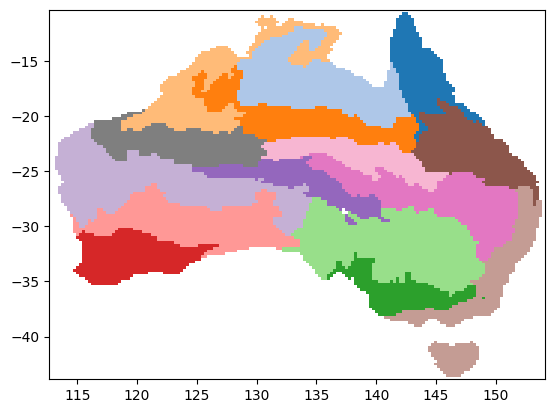

In [4]:
plt.pcolor(lsmdf.longitude,lsmdf.latitude,idxmap,cmap='tab20',
           vmin=0.5,vmax=20.5,alpha=1,snap=True,rasterized=True,zorder=-1)